# Imports

In [2]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.coordinates import FK5
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
import healpy as hp
import matplotlib.pyplot as plt
from astropy.coordinates import Angle
from astropy import units
from scipy.interpolate import RectBivariateSpline
from scipy import interpolate
import copy
import os
import sys
from tqdm.notebook import tqdm
from tqdm import tqdm
import glob
import h5py
import matplotlib
# from src2.ms_fit_joint import *
from src2.fit_funcs import *
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams["font.size"] = "18"
PATH="../Sensitivty_files/Sky_spectrum/"
import scipy.io
import seaborn as sns
sns.set_style("whitegrid")

## Load necessary files and store constants

In [4]:
data21   = scipy.io.loadmat('./Sensitivty_files/Sky_spectrum/Data_18March_wMFP.mat')
data21   = data21['Data2']/1e3 
fr       = np.loadtxt('./Sensitivty_files/Sky_spectrum/freq_saras.txt') #Frequency in MHz
signal   = interpolate.interp1d(fr, data21)

# Convolve sky + RFI with beam pattern

In [5]:
import h5py
filename = '/home/saurabhs/Documents/Yogen_starfire/Farfield244KHz/pratush_space.h5'
files=h5py.File(filename)
temps=files['T_A_only_beam'][:]

In [6]:
temps.shape
temps[:,:]+=300

In [7]:
RFI = np.load('/home/saurabhs/Documents/Yogen_starfire/skymodels/power_output.npy',allow_pickle=True)
RFI=RFI.astype(np.float64)

In [8]:
# no RFI pix no 2990
# 3 lines 3071
# worst location 380

In [9]:
temps+=RFI[1,380,:]

## Add system noise

In [10]:
tau=158.69*3600
sigma=np.zeros(np.shape(temps))
for i in range(sigma.shape[0]):
    for j in range(sigma.shape[1]):
        sigma[i,j]=(70+temps[i,j])/(np.sqrt((1e6)*tau))
        temps[i,j]+=np.random.normal(0,1,1)*sigma[i,j]


/tmp/ipykernel_572100/3429330576.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  temps[i,j]+=np.random.normal(0,1,1)*sigma[i,j]


## Residuals for null hypothesis

In [11]:
freq=np.arange(55,110,0.244)

In [12]:
freq_null=copy.deepcopy(freq)
avg_spectra = np.nanmean(temps, axis=0) 
avg_spectra = np.asarray(avg_spectra, dtype=np.float64)
e= sigma[100,:]

In [13]:
flags = avg_spectra>1e4


In [14]:
flags

array([ True, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [15]:
avg_spectra=avg_spectra[~flags]
freq_null = freq_null[~flags]
e = e[~flags]
# Codes taken from investigation_cleaner.ipynb

for i in range(3,11):
    print(i)
    initial_ = np.zeros(i, dtype='float128')
    if i ==3:
        initial_ = np.polyfit(y= np.log10(avg_spectra), x = rescale(freq_null), deg = 2)
    if i > 3:
        if para_new[0] ==0:
            p_order = len(para_new)-2
            break
        initial_[1:] = np.array(para_new, dtype='float128')
    para_new,res_cons,fit_curve_mag, chi_mag = chi_dunk_DC(x1=freq_null,y1=avg_spectra,\
                                             p00=initial_, gloss = True, keju_inf=1,\
                                               e1=e,iterations=50)
    

3
initial_DC


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [ -0.36317696   3.32999861 271.22753147] 

Residual rms : 0.38945227822709877
DC_component: 271.2275314727923
4
initial_DC


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [-2.42381874e-03 -3.69387733e-01  3.32320528e+00  3.03683679e+02] 

Residual rms : 0.013982352929407771
DC_component: 303.68367879036504
5
initial_DC


  0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
rms_null = np.sqrt(np.mean(res_cons**2))
print(rms_null)

0.00021048638435978992


## Inject 21 cm signal

In [14]:
data21   = scipy.io.loadmat('../Sensitivty_files/Sky_spectrum/Data_18March_wMFP.mat')
data21   = data21['Data2']/1e3 
fr       = np.loadtxt('../Sensitivty_files/Sky_spectrum/freq_saras.txt') #Frequency in MHz
signal   = interpolate.interp1d(fr, data21)
# T21=  signal(freq)[100]
freq_alt=copy.deepcopy(freq)

## Loop through each CD models and get residuals

In [15]:
import time

In [16]:
residuals=[]
rms=[]
confidence=[]
time_elapsed=[]
for i in range(T21.shape[0]):
    st_time = time.time()
    T21=  signal(freq)[i] #max 263 
    freq_alt=copy.deepcopy(freq)
    avg_spectra1 = np.mean(temps, axis=0)+T21

    avg_spectra1 = np.asarray(avg_spectra1, dtype=np.float64)
    avg_spectra1 = avg_spectra1[~flags]
    freq_alt = freq_alt[~flags]
    
    # Codes taken from investigation_cleaner.ipynb

    for i in range(3,11):
        print(i)
        initial_ = np.zeros(i, dtype='float128')
        if i ==3:
            initial_ = np.polyfit(y= np.log10(avg_spectra1), x = rescale(freq_alt), deg = 2)
        if i > 3:
            if para_new1[0] ==0:
                p_order = len(para_new1)-2
                break
            initial_[1:] = np.array(para_new1, dtype='float128')
        para_new1,res_cons1,fit_curve_mag1, chi_mag1 = chi_dunk(x1=freq_alt,y1=avg_spectra1,\
                                                 p00=initial_, gloss = True, keju_inf=1,\
                                                   e1=e,iterations=50)
        
    residuals.append(res_cons1)
    rms.append(np.sqrt(np.mean(res_cons1**2)))
    confidence.append((np.sqrt(np.std(res_cons1)**2-np.std(res_cons)**2))/np.std(res_cons))
    end_time=time.time()
    time_elapsed.append(end_time-st_time)
    

3
initial_6


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [ 0.01494638 -0.31954087  3.38259678] 

Residual rms : 2.4789464300223236
4
initial_6


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [ 0.00360508  0.01554678 -0.3225865   3.38173036] 

Residual rms : 0.06225168496279723
5
initial_6


...

Coefficients : [-2.62677467e-05 -2.45461949e-05  3.85412686e-04  3.84154575e-03
  1.52028160e-02 -3.22801027e-01  3.38173486e+00] 

Residual rms : 0.00047113089839488284
8
initial_6


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [-8.36072040e-06 -3.08433168e-05 -9.48477046e-06  3.94485840e-04
  3.83508044e-03  1.51982991e-02 -3.22801305e-01  3.38173489e+00] 

Residual rms : 0.00032578167478239
9
initial_6


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [ 0.00000000e+00 -8.36072043e-06 -3.08433168e-05 -9.48477140e-06
  3.94485845e-04  3.83508044e-03  1.51982991e-02 -3.22801305e-01
  3.38173489e+00] 

Residual rms : 0.00032578166059973375
10


In [224]:
import matplotlib.cm as cm

## No RFI scenario

In [449]:
norfi_conf=np.load('/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/mock_sims/fitparams/no_lines/confidence.npy')

/tmp/ipykernel_326996/233331198.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
/tmp/ipykernel_326996/233331198.py:21: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label=r'$\sigma$ confidence')


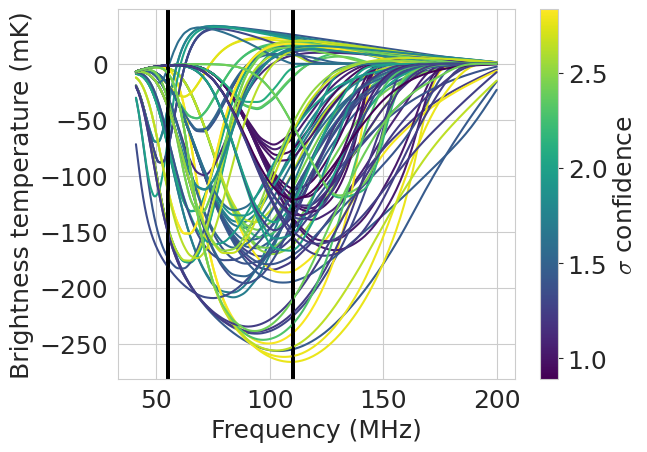

In [451]:
ind_3=np.where((norfi_conf>0)&(norfi_conf<3))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_3]  
x = saras_freq
y_values = T21
values = norfi_conf[ind_3]  

# Create a colormap
cmap = cm.get_cmap('viridis')

norm = plt.Normalize(values.min(), values.max())

for i in range(len(ind_3)):
    
    plt.plot(saras_freq,T21[i,:]*1000,c=cmap(norm(values[i])))
    plt.axvline(x=55,c='black')
    plt.axvline(x=110,c='black')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Brightness temperature (mK)')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, label=r'$\sigma$ confidence')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/NRF_HC.pdf',bbox_inches='tight')

## Three RFI lines flagged

In [405]:
rfi_conf=np.load('/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/mock_sims/fitparams/no_lines/confidence.npy')

/tmp/ipykernel_326996/1869001566.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
/tmp/ipykernel_326996/1869001566.py:21: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Value')


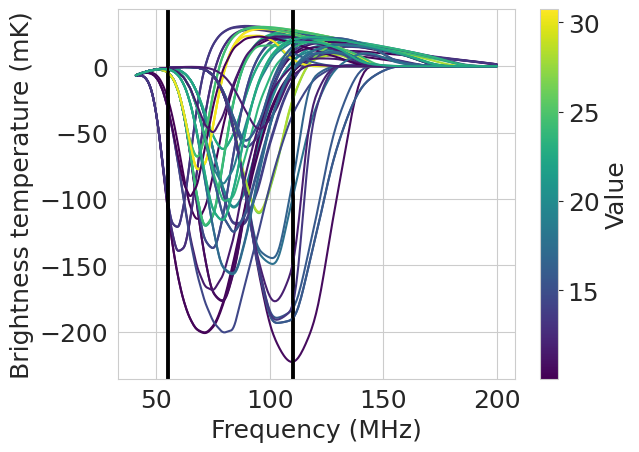

In [406]:
ind_3=np.where((rfi_conf>10))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_3] #max 263 
x = saras_freq
y_values = T21
values = rfi_conf[ind_3]  

# Create a colormap
cmap = cm.get_cmap('viridis')

norm = plt.Normalize(values.min(), values.max())

for i in range(len(ind_3)):
    
    plt.plot(saras_freq,T21[i,:]*1000,c=cmap(norm(values[i])))
    plt.axvline(x=55,c='black')
    plt.axvline(x=110,c='black')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Brightness temperature (mK)')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, label='Value')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/MRF_HC.pdf',bbox_inches='tight')

## High channel loss

In [531]:
highrf_conf=np.load('/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/mock_sims/fitparams/high_rfi/confidence.npy')

/tmp/ipykernel_326996/1371819694.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
/tmp/ipykernel_326996/1371819694.py:24: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Value')


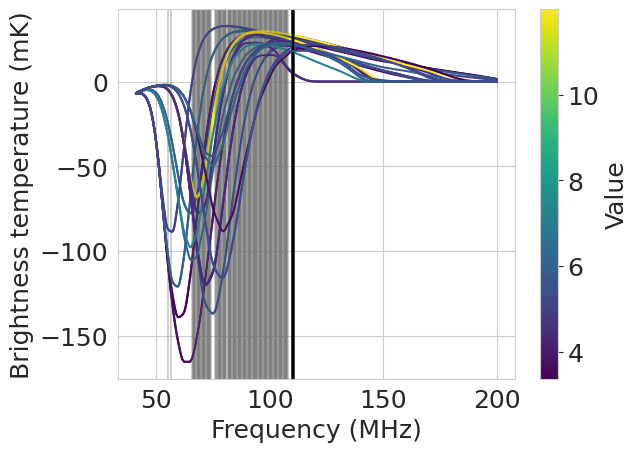

In [421]:
ind_3=np.where((highrf_conf>3))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_3] #max 263 
x = saras_freq
y_values = T21
values = highrf_conf[ind_3]  

# Create a colormap
cmap = cm.get_cmap('viridis')

norm = plt.Normalize(values.min(), values.max())

for k in range(len(ind_3)):
    
   
    for i in range(len(freq[flags])):
        plt.axvline(x=freq[flags][i],c='gray',alpha=0.01)
    plt.axvline(x=110,c='black')
#     plt.axvline(x=55,c='black')
    abc=plt.plot(saras_freq,T21[k,:]*1000,c=cmap(norm(values[k])))
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Brightness temperature (mK)')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, label='Value')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/HRF_HC.pdf',bbox_inches='tight')

In [533]:
flags=avg_spectra>1e4

In [655]:
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
matplotlib.rcParams["mathtext.bf"]

'sans:bold'

/tmp/ipykernel_326996/1231604264.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap1 = cm.get_cmap('viridis')
/tmp/ipykernel_326996/1231604264.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = cm.get_cmap('viridis')
/tmp/ipykernel_326996/1231604264.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap3 = cm.get_cmap('viridis')


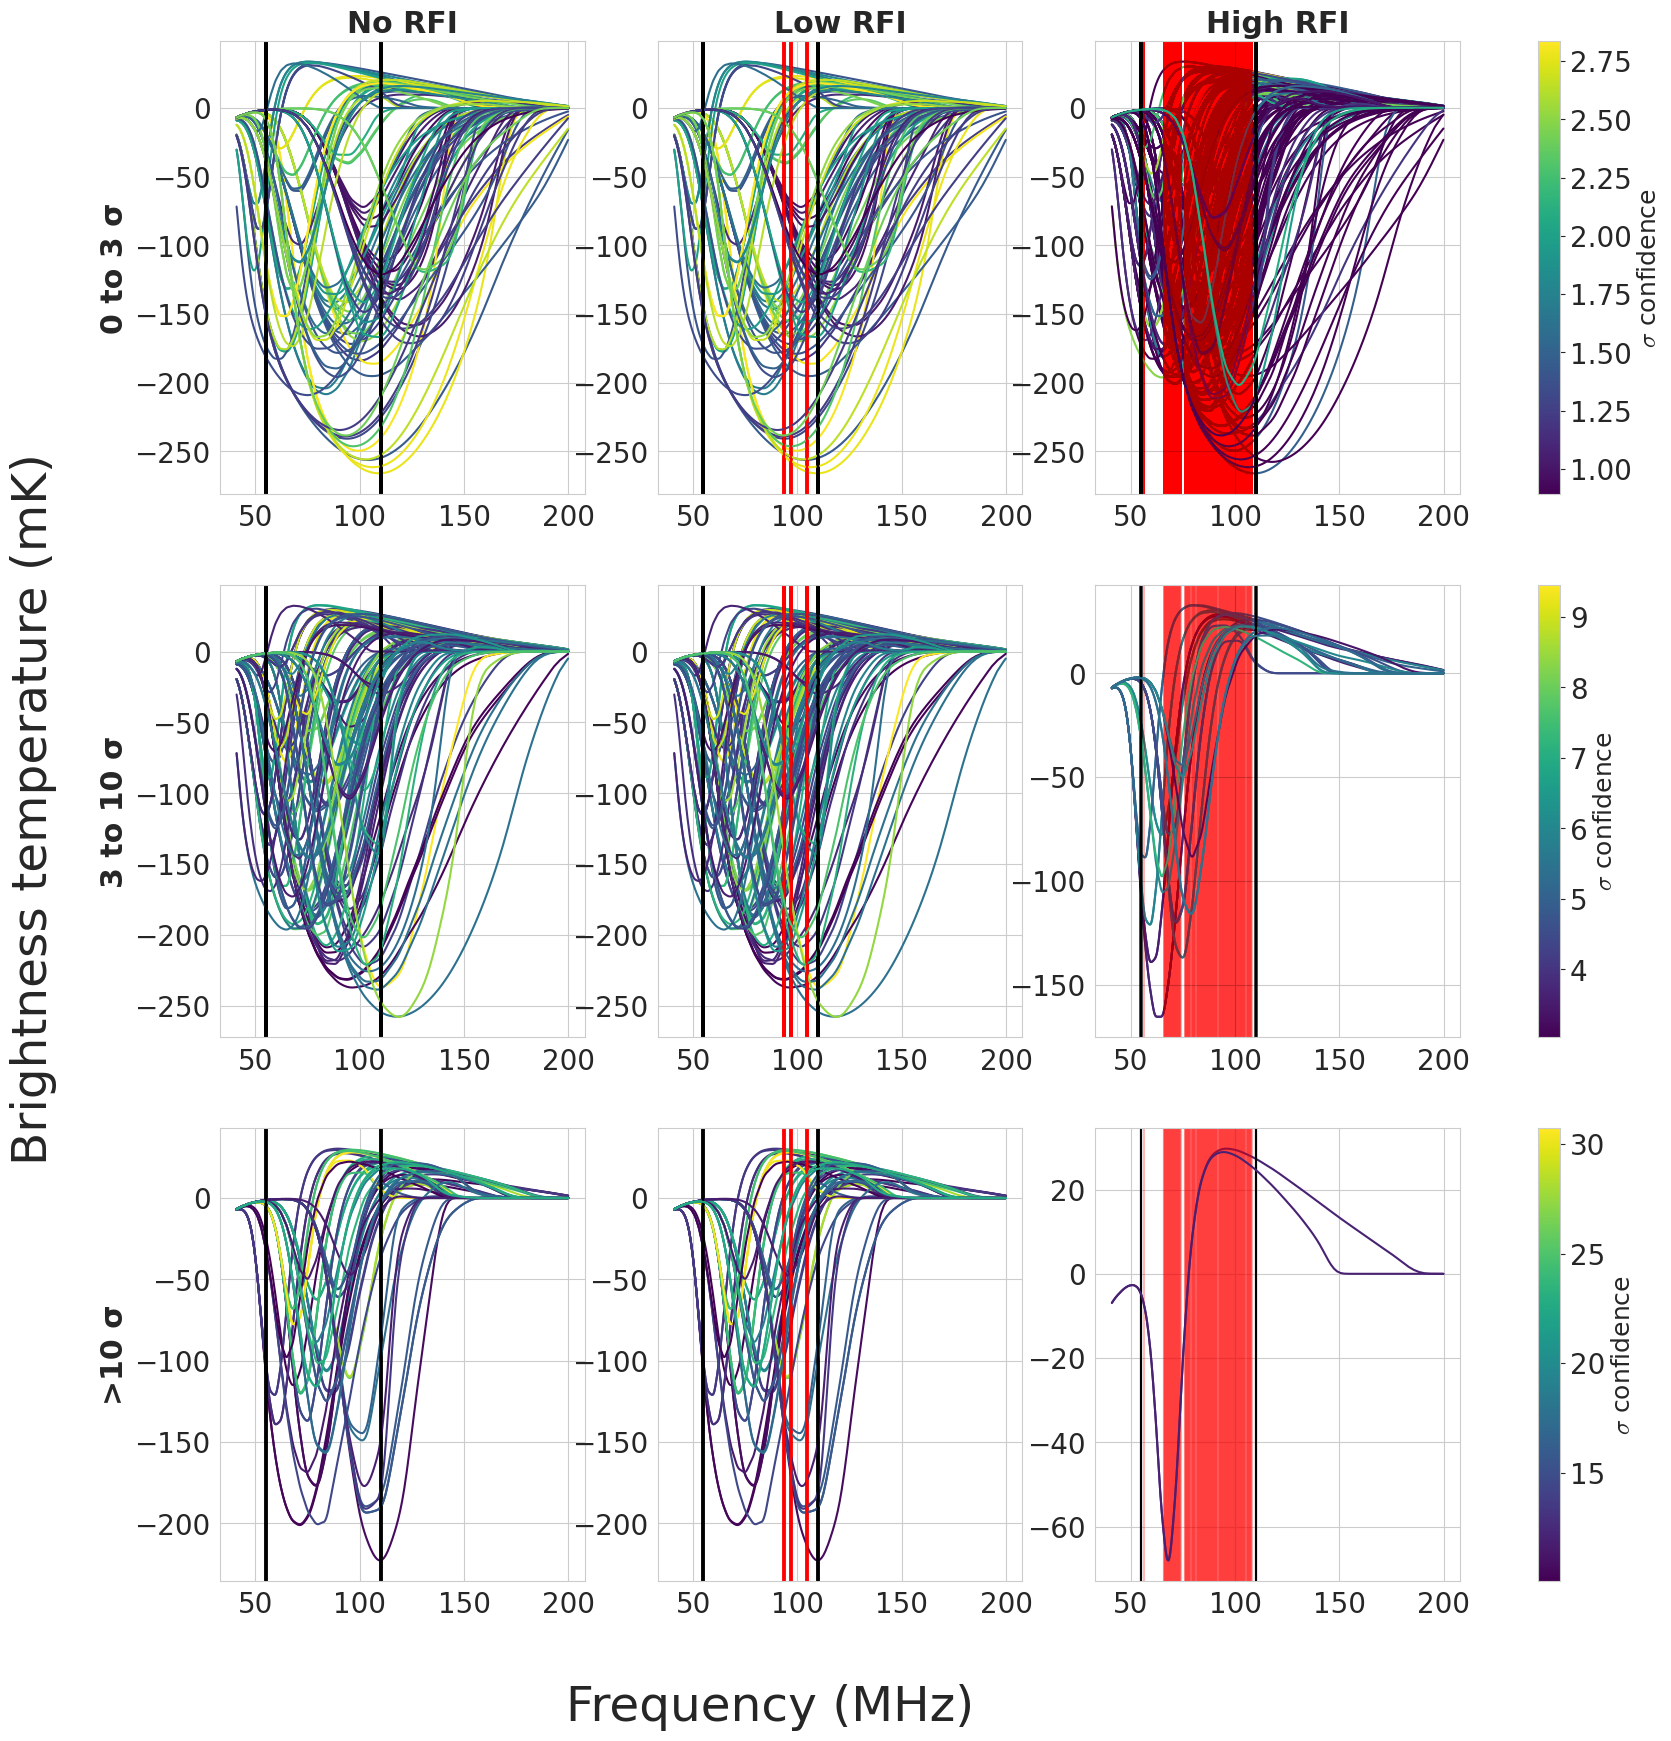

In [707]:
### initialize subplot ###
fig, axs = plt.subplots(nrows = 3,
                        ncols = 3,
                        figsize= (20, 20)
                       )

# plot LRF_LC
ind_00=np.where((norfi_conf>0)&(norfi_conf<3))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_00]  
x = saras_freq
y_values = T21
values00 = norfi_conf[ind_00]  

cmap1 = cm.get_cmap('viridis')


norm1 = plt.Normalize(values00.min(), values00.max())

for i in range(len(ind_00)):
    
    axs[0,0].plot(saras_freq,T21[i,:]*1000,c=cmap1(norm1(values00[i])))
    axs[0,0].axvline(x=55,c='black')
    axs[0,0].axvline(x=110,c='black')
sm1 = cm.ScalarMappable(cmap=cmap1, norm=norm1)
fig.colorbar(sm1, label=r'$\sigma$ confidence',ax=axs[0,:])   


# plot LRF_MC
ind_10=np.where((norfi_conf>3)&(norfi_conf<10))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_10]  
x = saras_freq
y_values = T21
values10 = norfi_conf[ind_10]  

cmap2 = cm.get_cmap('viridis')
norm2 = plt.Normalize(values10.min(), values10.max())

for i in range(len(ind_10)):
    
    axs[1,0].plot(saras_freq,T21[i,:]*1000,c=cmap2(norm2(values10[i])))
    axs[1,0].axvline(x=55,c='black')
    axs[1,0].axvline(x=110,c='black')
    
sm2 = cm.ScalarMappable(cmap=cmap2, norm=norm2)
fig.colorbar(sm2, label=r'$\sigma$ confidence',ax=axs[1,:])

#  LRF_HC
ind_20=np.where((norfi_conf>10))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_20]  
x = saras_freq
y_values = T21
values20 = norfi_conf[ind_20]  

cmap3 = cm.get_cmap('viridis')

norm3 = plt.Normalize(values20.min(), values20.max())

for i in range(len(ind_20)):
    
    axs[2,0].plot(saras_freq,T21[i,:]*1000,c=cmap3(norm3(values20[i])))
    axs[2,0].axvline(x=55,c='black')
    axs[2,0].axvline(x=110,c='black')
    
sm3 = cm.ScalarMappable(cmap=cmap3, norm=norm3)
fig.colorbar(sm3, label=r'$\sigma$ confidence',ax=axs[2,:])

# MRF_LC
ind_01=np.where((rfi_conf>0)&(rfi_conf<3))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_01] #max 263 
x = saras_freq
y_values = T21
values01 = rfi_conf[ind_01]  
flags1=[159, 171, 203]
# Create a colormap




for k in range(len(ind_01)):
    
   
    for i in range(3):
        axs[0,1].axvline(x=freq[flags1][i],c='red',alpha=0.5)
    axs[0,1].axvline(x=110,c='black')
    axs[0,1].axvline(x=55,c='black')
    axs[0,1].plot(saras_freq,T21[k,:]*1000,c=cmap1(norm1(values01[k])))

# MRF_MC
ind_11=np.where((rfi_conf>3)&(rfi_conf<10))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_11] #max 263 
x = saras_freq
y_values = T21
values11 = rfi_conf[ind_11]  
flags1=[159, 171, 203]



for k in range(len(ind_11)):
    
   
    for i in range(3):
        axs[1,1].axvline(x=freq[flags1][i],c='red',alpha=0.8)
    axs[1,1].axvline(x=110,c='black')
    axs[1,1].axvline(x=55,c='black')
    axs[1,1].plot(saras_freq,T21[k,:]*1000,c=cmap2(norm2(values11[k])))

# MRF_HC
ind_21=np.where((rfi_conf>10))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_21] #max 263 
x = saras_freq
y_values = T21
values21 = rfi_conf[ind_21]  
flags1=[159, 171, 203]
# Create a colormap


for k in range(len(ind_21)):
    
   
    for i in range(3):
        axs[2,1].axvline(x=freq[flags1][i],c='red',alpha=0.9)
    axs[2,1].axvline(x=110,c='black')
    axs[2,1].axvline(x=55,c='black')
    axs[2,1].plot(saras_freq,T21[k,:]*1000,c=cmap3(norm3(values21[k])))


# HRF_LC
ind_02=np.where((highrf_conf>0)&(highrf_conf<3))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_02] #max 263 
x = saras_freq
y_values = T21
values02 = highrf_conf[ind_02]  

# Create a colormap


for k in range(len(ind_02)):
    
   
    for i in range(len(freq[flags])):
        axs[0,2].axvline(x=freq[flags][i],c='red',alpha=0.01)
    axs[0,2].axvline(x=110,c='black')
    axs[0,2].axvline(x=55,c='black')
    axs[0,2].plot(saras_freq,T21[k,:]*1000,c=cmap1(norm1(values02[k])))

# HRF_MC
ind_12=np.where((highrf_conf>3)&(highrf_conf<10))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_12] #max 263 
x = saras_freq
y_values = T21
values12 = highrf_conf[ind_12]  

# Create a colormap


for k in range(len(ind_12)):
    
   
    for i in range(len(freq[flags])):
        axs[1,2].axvline(x=freq[flags][i],c='red',alpha=0.01)
    axs[1,2].axvline(x=110,c='black')
    axs[1,2].axvline(x=55,c='black')
    axs[1,2].plot(saras_freq,T21[k,:]*1000,c=cmap2(norm2(values12[k])))

# HRF_HC
ind_22=np.where((highrf_conf>10))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_22] #max 263 
x = saras_freq
y_values = T21
values22 = highrf_conf[ind_22]  

# Create a colormap


for k in range(len(ind_22)):
    
   
    for i in range(len(freq[flags])):
        axs[2,2].axvline(x=freq[flags][i],c='red',alpha=0.15)
    axs[2,2].axvline(x=110,c='black')
    axs[2,2].axvline(x=55,c='black')
    axs[2,2].plot(saras_freq,T21[k,:]*1000,c=cmap3(norm3(values22[k])))

axs[0, 0].title.set_text("No RFI")
axs[0, 0].title.set_fontweight("bold")
axs[0, 1].title.set_fontweight("bold")
axs[0, 2].title.set_fontweight("bold")

axs[0, 1].title.set_text("Low RFI")
axs[0, 2].title.set_text("High RFI")


fig.text(0.4, 0.04, 'Frequency (MHz)', ha='center',fontsize=35)
rows = ['0 to 3 σ', '3 to 10 σ', '>10 σ']
for ax, row in zip(axs[:,0], rows):
    ax.set_ylabel(row, rotation='vertical', size='large',fontweight='bold')
    
fig.text(0.02, 0.5, 'Brightness temperature (mK) ', va='center', rotation='vertical',fontsize=35)
# fig.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/best_plot.pdf',dpi=600,bbox_inches='tight')

In [646]:
plt.plot(res_cons)

In [619]:
rows = ['Row {}'.format(row) for row in ['A', 'B', 'C', 'D']]

In [620]:
rows

['Row A', 'Row B', 'Row C', 'Row D']

/tmp/ipykernel_326996/4156189864.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


AttributeError: module 'matplotlib.pyplot' has no attribute 'color'

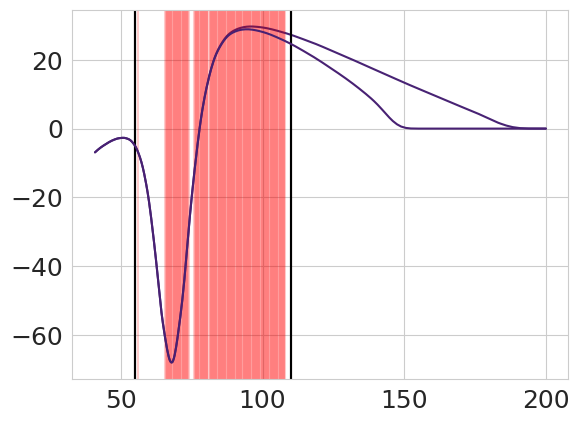

In [543]:
ind_22=np.where((highrf_conf>10))[0]
saras_freq=np.arange(41,200,0.244)
T21=  signal(saras_freq)[ind_22] #max 263 
x = saras_freq
y_values = T21
values = highrf_conf[ind_22]  

# Create a colormap
cmap = cm.get_cmap('viridis')

norm = plt.Normalize(values.min(), values.max())

for k in range(len(ind_22)):
    
   
    for i in range(len(freq[flags])):
        plt.axvline(x=freq[flags][i],c='red',alpha=0.1)
    plt.axvline(x=110,c='black')
    plt.axvline(x=55,c='black')
    plt.plot(saras_freq,T21[k,:]*1000,c=cmap(norm3(values22[k])))


In [575]:
min_temps=np.array([1.15631696e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.44330884e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.09754284e+00, 2.42219024e-01, 2.53648683e-01, 2.22510748e-01,
       2.98938758e-01, 3.19309121e-01, 2.74086166e-01, 2.24484057e-01,
       2.24487595e-01, 2.39198965e-01, 2.06089932e-01, 1.66402503e-01,
       2.26512043e-01, 2.24632801e-01, 2.46713961e-01, 2.31883011e-01,
       2.29509701e-01, 1.60933671e-01, 2.03579093e-01, 1.83260851e-01,
       1.08233946e-01, 1.54980324e-01, 1.22916560e-01, 8.80007469e-02,
       9.67711812e-02, 1.45470929e-01, 1.66037396e-01, 7.66175538e-02,
       1.11311019e-01, 1.14284182e-01, 3.20861890e-02, 3.30476751e-02,
       4.32270179e-03, 7.01690682e-03, 4.46990104e-03, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.96308885e-03, 9.47860876e-05,
       2.45867585e-03, 3.10770445e-04, 1.18893300e-02, 5.27303010e-03,
       8.76571061e-04, 4.16798286e-03, 1.99818765e-03, 1.72248535e-03,
       5.05330602e-04, 1.39768557e-03, 2.32055033e-03, 9.52677638e-04,
       3.48699865e-03, 1.53901729e-03, 1.06006294e-02, 1.81677429e-03,
       4.22257512e-03, 6.93969958e-03, 8.48554364e-05, 0.00000000e+00,
       4.62294240e-03, 4.38786582e-03, 4.34979666e-03, 9.91792386e-04,
       5.50540921e-04, 1.22142172e-02, 2.07837097e-03, 9.19625024e-04,
       1.20639371e-03, 9.78124713e-04, 4.40921770e-02, 1.03934446e-03,
       6.25468835e-04, 3.98853443e-03, 5.63052212e-02, 7.32226804e-02,
       5.41245887e-02, 5.21079287e-02, 4.81417223e-02, 6.76073396e-02,
       7.48894175e-02, 5.16951999e-02, 5.75670107e-02, 4.91145759e-02,
       6.31532137e-02, 1.02609897e-01, 1.93508906e-01, 3.37737681e-01,
       3.64843613e-01, 2.09986492e-01, 2.22675828e-01, 2.86458011e-01,
       1.78329523e-01, 3.01726667e-01, 2.14156568e-01, 3.02277684e-01,
       8.08960004e-02, 2.76522568e-01, 9.64434151e-02, 2.13794896e-01,
       2.94762118e-01, 1.31861329e-01, 2.25263919e-01, 2.00512096e-01,
       3.12334303e-01, 8.81725353e-02, 1.89370593e-01, 2.44106364e-01,
       1.73900233e-01, 1.53688208e-01, 2.28997681e-01, 1.88134106e-01,
       2.18894972e-01, 1.94024971e-01, 1.71708622e-01, 1.03779019e-01,
       2.86470879e-01, 1.73967354e-01, 1.87791102e-01, 8.81270620e-02,
       2.78456727e-01, 1.28785454e-01, 1.39678048e-01, 1.06735589e-01,
       2.20338177e-01, 1.20471810e-01, 1.18412979e-01, 1.42582815e-01,
       8.66124130e-02, 1.60795570e-01, 6.66656849e-02, 6.07830508e-02,
       1.80784330e-01, 5.44612148e-02, 1.82959052e-01, 5.08821316e-02,
       2.62563646e-01, 1.10521668e-01, 2.07908319e-01, 1.05793106e-01,
       1.04508697e-01, 2.03806876e-01, 9.66616234e-02, 1.77014835e-01,
       1.16402764e-01, 1.18754579e-01, 1.23612671e-01, 2.11430828e-01,
       4.92643424e-02, 1.27228368e-01, 1.08153318e-01, 1.68936570e-01,
       1.41845877e-01, 1.84899996e-01, 1.23974801e-01, 8.89050357e-02,
       7.45275194e-02, 2.63536256e-01, 5.82873942e-02, 1.65376820e-01,
       1.01405092e-01, 1.55235792e-01, 5.85147714e-02, 1.88519248e-01,
       4.07581582e-02, 9.14240543e-02, 9.94188372e-02, 6.76408378e-02,
       6.77567571e-02, 5.52198914e-02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.83969762e-04])

In [580]:
avgnew=np.mean(temps,axis=0)

In [582]:
avgnew+=min_temps

In [586]:
e=np.random.normal(0,1,226)*1e-3

In [587]:

# Codes taken from investigation_cleaner.ipynb

for i in range(3,11):
    print(i)
    initial_ = np.zeros(i, dtype='float128')
    if i ==3:
        initial_ = np.polyfit(y= np.log10(avgnew), x = rescale(freq), deg = 2)
    if i > 3:
        if para_new[0] ==0:
            p_order = len(para_new)-2
            break
        initial_[1:] = np.array(para_new, dtype='float128')
    para_new,res_cons,fit_curve_mag, chi_mag = chi_dunk_DC(x1=freq,y1=avgnew,\
                                             p00=initial_, gloss = True, keju_inf=1,\
                                               e1=e,iterations=50)
    

3
initial_DC


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [ -0.366384     3.33171831 268.34995221] 

Residual rms : 0.13507957454129885
DC_component: 268.34995220506767
4
initial_DC


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [-2.62284819e-03 -3.73344212e-01  3.32394994e+00  3.05936086e+02] 

Residual rms : 0.03325110154461849
DC_component: 305.9360864381046
5
initial_DC


...

Coefficients : [-3.96885546e-04  1.48266548e-04  3.37578927e-03  9.69314514e-03
 -3.43395809e-01  3.36028076e+00  1.21899475e+02] 

Residual rms : 0.021791968824779316
DC_component: 121.89947465708559
8
initial_DC


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [ 1.36877626e-04 -3.84763780e-04 -1.29345488e-04  2.45303037e-03
  5.57165940e-03 -3.54401300e-01  3.34657029e+00  1.93130756e+02] 

Residual rms : 0.021299822040875098
DC_component: 193.13075613898218
9
initial_DC


  0%|          | 0/50 [00:00<?, ?it/s]

Coefficients : [ 0.00000000e+00  1.36877626e-04 -3.84763780e-04 -1.29345488e-04
  2.45303037e-03  5.57165940e-03 -3.54401300e-01  3.34657029e+00
  1.93130756e+02] 

Residual rms : 0.02129982204086544
DC_component: 193.13075614418148
10


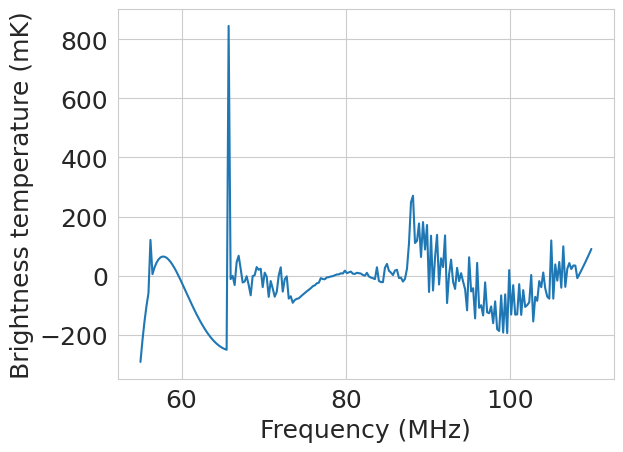

In [593]:
plt.plot(freq,res_cons*1000)
plt.ylabel('Brightness temperature (mK)')
plt.xlabel('Frequency (MHz)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/L2_residues.pdf',bbox_inches='tight',dpi=600)

In [606]:
(np.sum((highrf_conf>10)&(highrf_conf>10))/len(highrf_conf))*100

0.7604562737642585

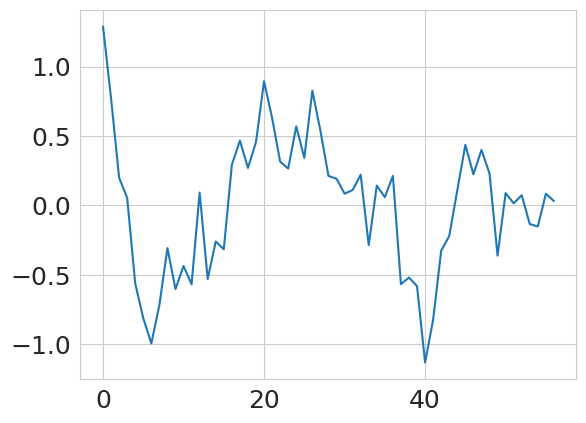

In [610]:
plt.plot(res_cons1*1000)
# plt.plot(res_cons)